In [79]:
import matplotlib.pyplot as plt
import ProcessEmbryo as PrEm
print(PrEm.__version__)

25.06.04


In [178]:
loaded_stack = PrEm.get_stack(r'C:\Users\denis\Desktop\Posfai lab\Alana_fucci\250320_stack0\processed.stack')

Text(0.5, 1.0, '250320_stack0')

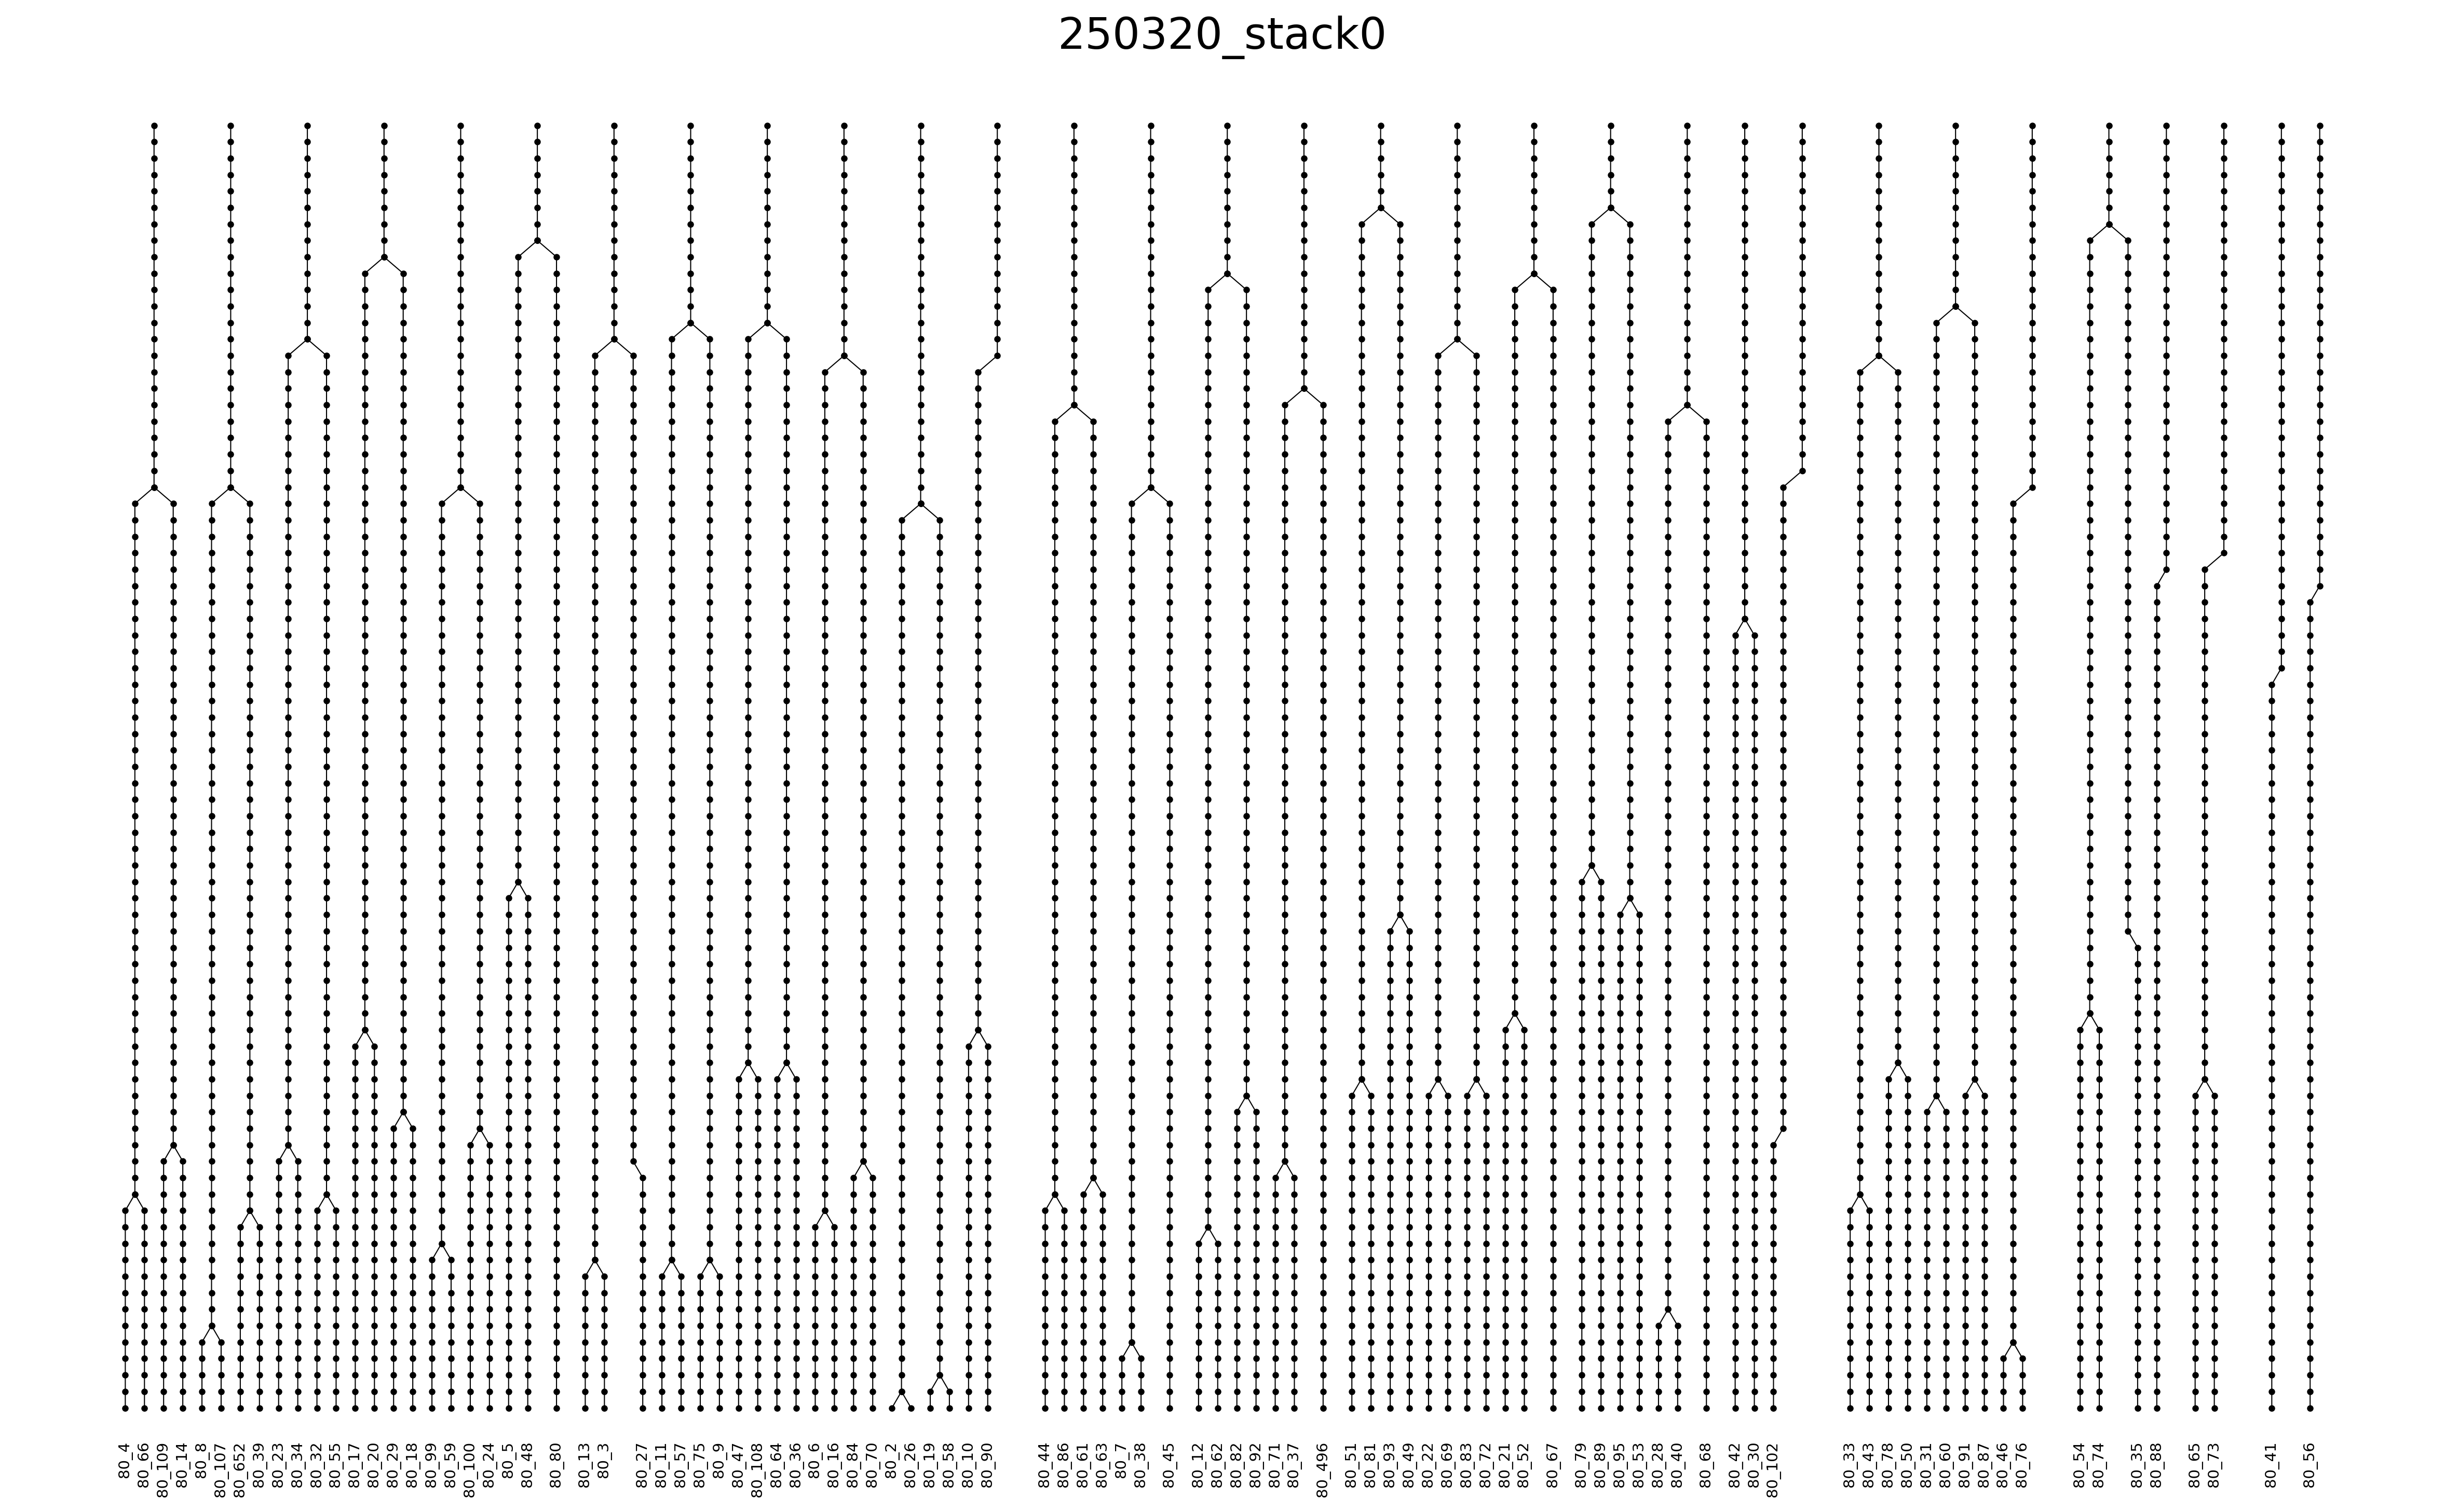

In [179]:
spacing = 5
space_shrinking = 2
padding = 10
encounter = []
encounter_x = []
last_x = 0

plt.figure(figsize=(20, 12), dpi=300, facecolor='white')

for cell_i in range(len(loaded_stack[0])):
    cur_x = last_x
    stop_here = False
    just_updated = False
    skeweness = 'left'
    shrink_counter = 0

    cell_plot_x = []
    cell_plot_y = []

    cell = loaded_stack[0][cell_i]

    for i in range(1, len(cell[1])):

        cell_ID = [cell[1][len(cell[1])-i][0], cell[1][len(cell[1])-i][1]]
        if cell_ID in cell[2]:
            if cell_ID in encounter:
                cur_x = encounter_x[encounter.index(cell_ID)][0]
                cell_plot_x.append(cur_x)
                cell_plot_y.append(encounter[encounter.index(cell_ID)][0])

                space_factor = encounter_x[encounter.index(cell_ID)][2]
                last_cur_x = cur_x

                if encounter_x[encounter.index(cell_ID)][1] == 'left':
                    skeweness = 'right'
                    skew_factor = 1
                else:
                    skew_factor = -1
                
                for j in range(2, len(cell_plot_x)+1):
                    tmp_ID = [cell[1][len(cell[1])-i+j-1][0], cell[1][len(cell[1])-i+j-1][1]]
                    cell_plot_x[len(cell_plot_x)-j] = last_cur_x + skew_factor * space_factor
                    
                    if tmp_ID in cell[2]:
                        last_cur_x = cell_plot_x[len(cell_plot_x)-j]
                        space_factor = space_factor / 2
                    
                    if tmp_ID in encounter:
                        encounter_x[encounter.index(tmp_ID)][0] = cell_plot_x[len(cell_plot_x)-j]
                        encounter_x[encounter.index(tmp_ID)][1] = skeweness
                        encounter_x[encounter.index(tmp_ID)][2] = space_factor

                stop_here = True
            else:
                cur_x += spacing * (space_shrinking ** shrink_counter)
                encounter.append(cell_ID)
                encounter_x.append([cur_x, skeweness, spacing * (space_shrinking ** shrink_counter)])
                shrink_counter += 1

        if stop_here:
            break
        
        cell_plot_x.append(cur_x)
        cell_plot_y.append(cell[1][len(cell[1])-i][0])

    plt.plot(cell_plot_x, cell_plot_y, marker='o', markersize=2, linewidth=0.5, color='black')
    plt.text(cell_plot_x[0], cell_plot_y[0] + 2, str(cell[1][len(cell[1])-1][0]) + '_' + str(cell[1][len(cell[1])-1][1]),
             rotation='vertical', horizontalalignment='center', verticalalignment='top', fontsize = 7, color = 'black')
    
    temp_last_x = max(cell_plot_x)
    if temp_last_x >= last_x:
        last_x = (temp_last_x - last_x) * 2 + last_x + padding

plt.axis('off')
plt.gca().invert_yaxis()
plt.title(loaded_stack[2][3][0], color = 'black', fontsize=20)

In [180]:
range_mins = loaded_stack[2][2][0]
range_maxs = loaded_stack[2][2][1]
for i in range(len(range_mins)):
    if i == 0:
        print('Histone:')
    else:
        print(f'Signal_{i}:')
    print(f'[{range_mins[i]:.2f} - {range_maxs[i]:.2f}]')

Histone:
[125.65 - 639.02]
Signal_1:
[117.23 - 816.38]


In [181]:
def hex_to_rgb(hex_code): # converts a hex color code to an RGB triplet
    hex_code = hex_code.lstrip('#') # Remove '#' if present
    return [int(hex_code[i:i+2], 16) for i in (0, 2, 4)]

def rgb_to_hex(color): # converts an RGB triplet to a hex color code
    return "#{:02x}{:02x}{:02x}".format(int(color[0]), int(color[1]), int(color[2]))

def color_interpol(colrange, fract): # generates a color hex interpolated between 2 points
    clr = colrange[0][0] + fract * (colrange[1][0] - colrange[0][0])
    clg = colrange[0][1] + fract * (colrange[1][1] - colrange[0][1])
    clb = colrange[0][2] + fract * (colrange[1][2] - colrange[0][2])
    return rgb_to_hex([clr, clg, clb])

Text(0.5, 1.0, '250320_stack0')

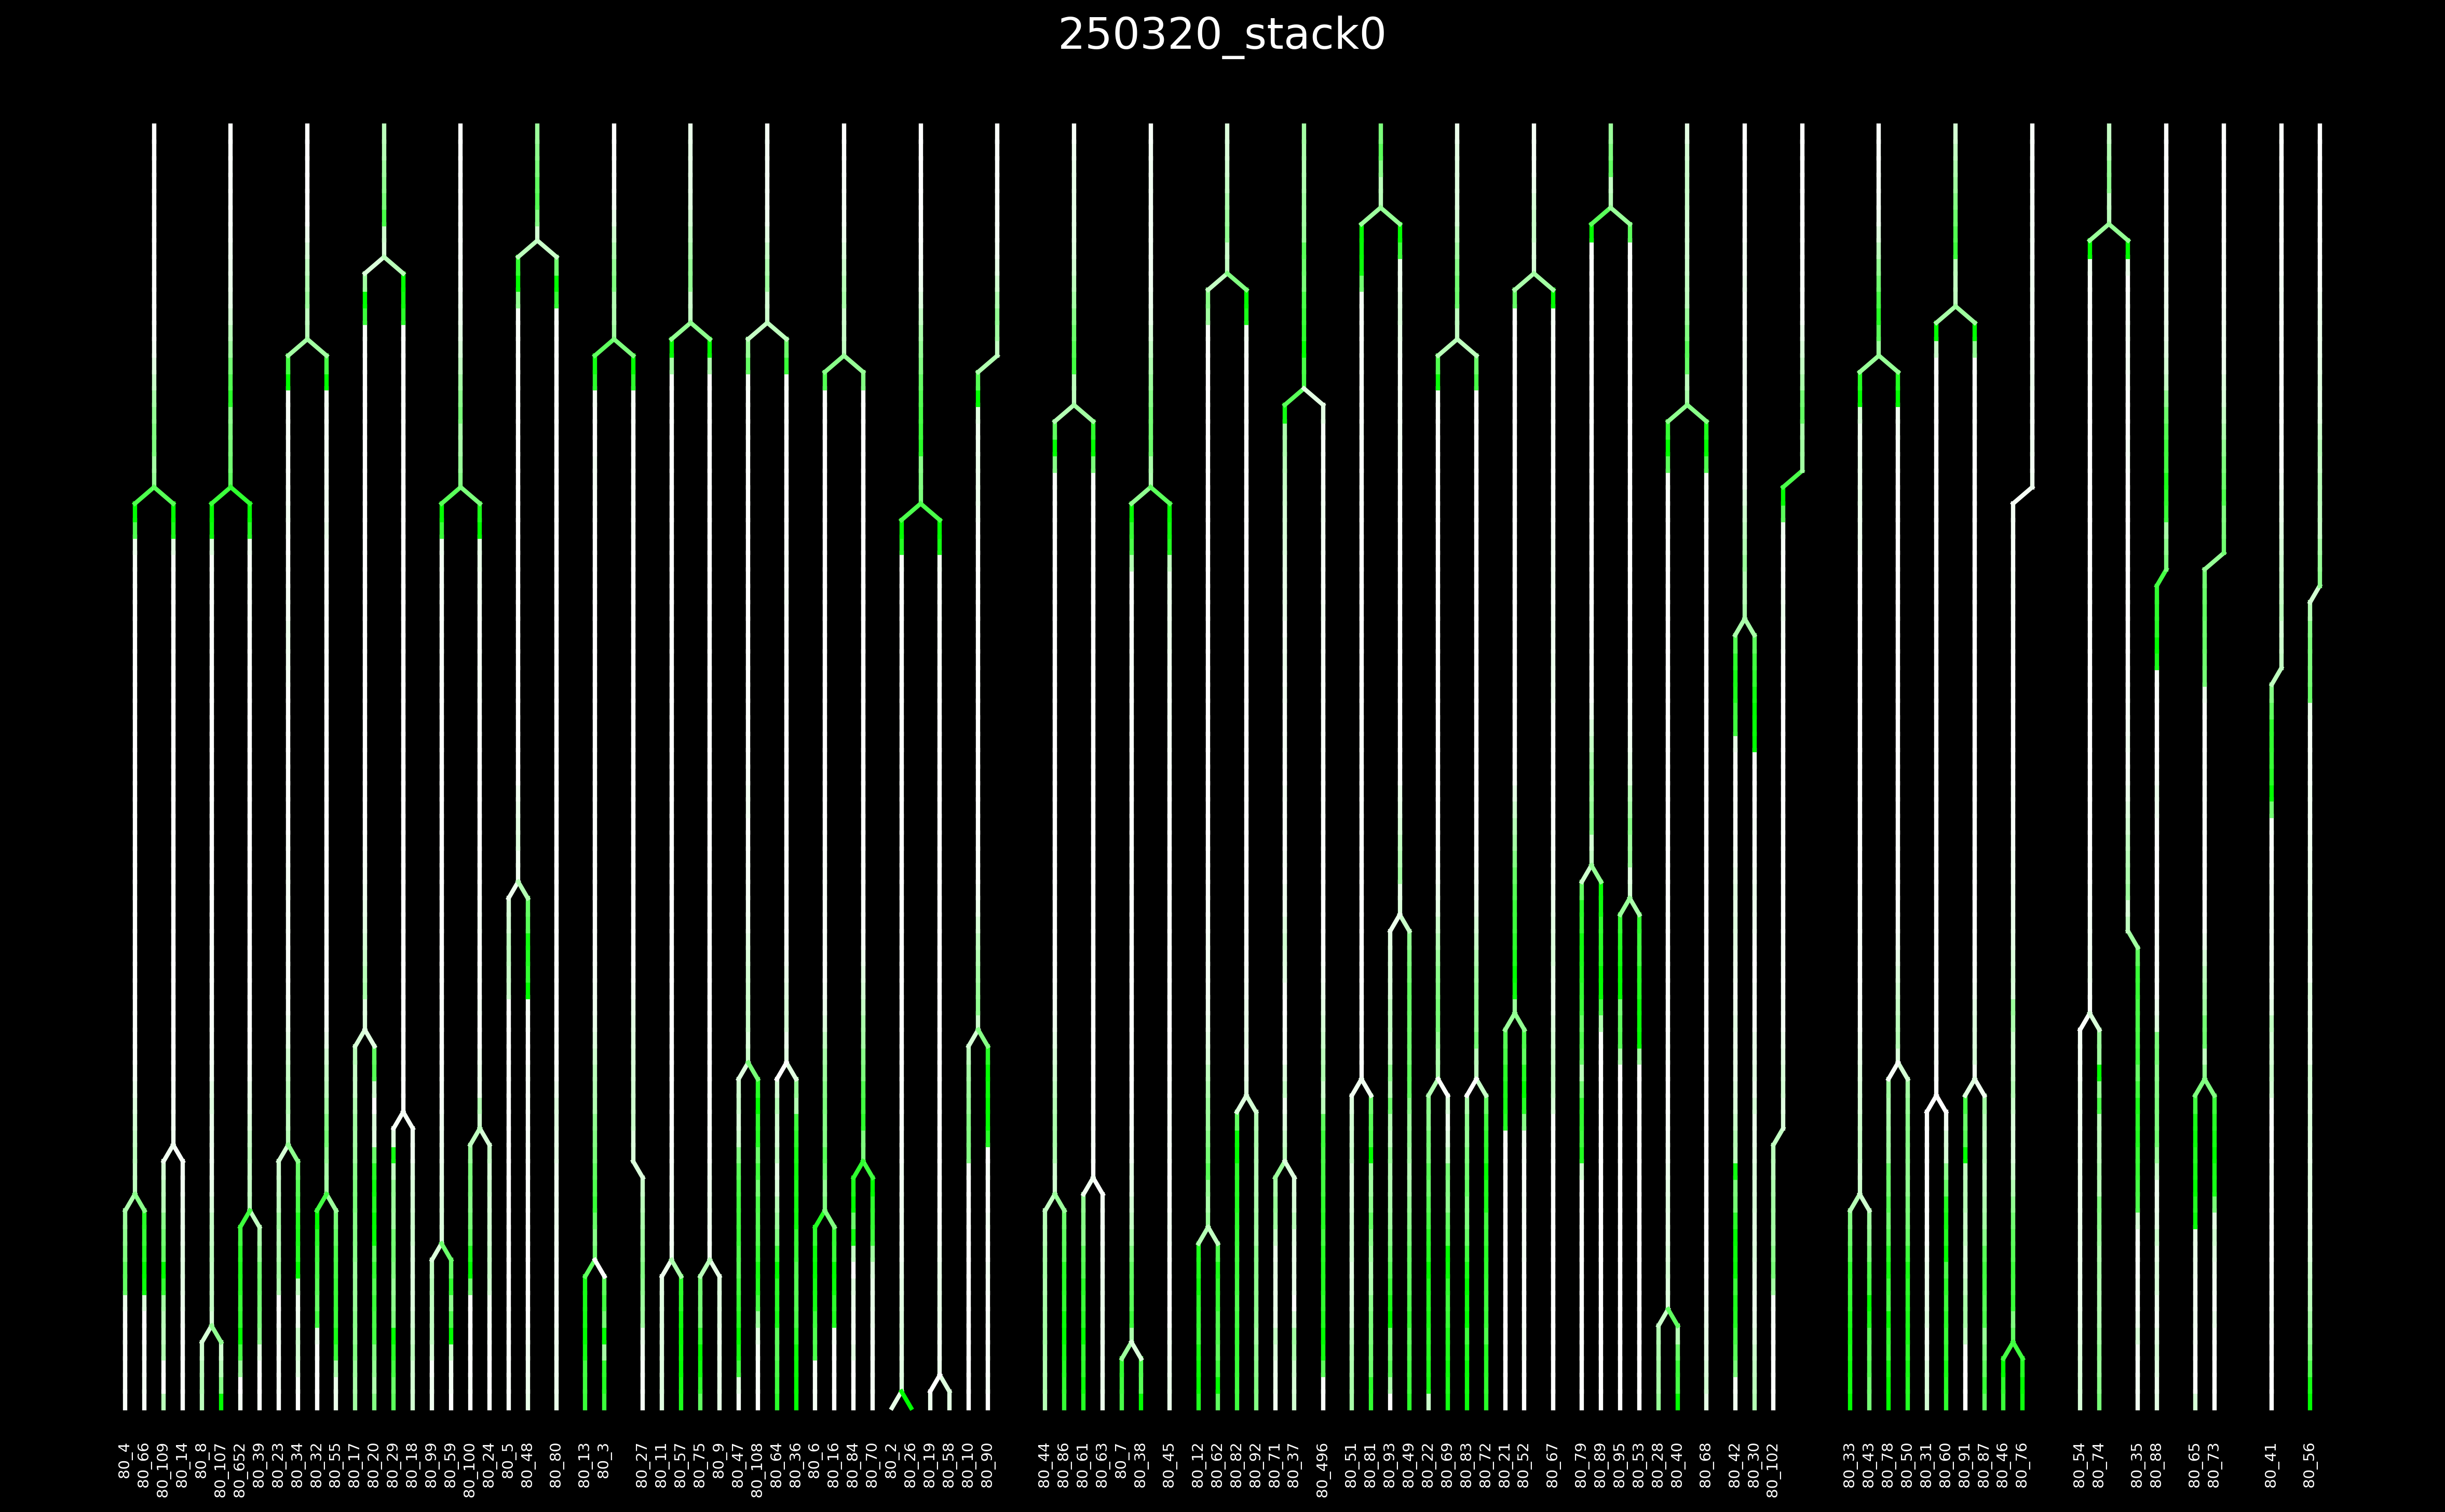

In [182]:
spacing = 5
space_shrinking = 2
padding = 10
encounter = []
encounter_x = []
last_x = 0

plt.figure(figsize=(20, 12), dpi=300, facecolor='black')

for cell_i in range(len(loaded_stack[0])):
    cur_x = last_x
    stop_here = False
    just_updated = False
    skeweness = 'left'
    shrink_counter = 0

    cell_plot_x = []
    cell_plot_y = []
    cell_plot_c = []

    cell = loaded_stack[0][cell_i]

    for i in range(1, len(cell[1])):

        cell_ID = [cell[1][len(cell[1])-i][0], cell[1][len(cell[1])-i][1]]
        cell_col = cell[1][len(cell[1])-i][6]
        
        if cell_ID in cell[2]:
            if cell_ID in encounter:
                cur_x = encounter_x[encounter.index(cell_ID)][0]
                cell_plot_x.append(cur_x)
                cell_plot_y.append(encounter[encounter.index(cell_ID)][0])
                cell_plot_c.append(cell_col)

                space_factor = encounter_x[encounter.index(cell_ID)][2]
                last_cur_x = cur_x

                if encounter_x[encounter.index(cell_ID)][1] == 'left':
                    skeweness = 'right'
                    skew_factor = 1
                else:
                    skew_factor = -1
                
                for j in range(2, len(cell_plot_x)+1):
                    tmp_ID = [cell[1][len(cell[1])-i+j-1][0], cell[1][len(cell[1])-i+j-1][1]]
                    cell_plot_x[len(cell_plot_x)-j] = last_cur_x + skew_factor * space_factor
                    
                    if tmp_ID in cell[2]:
                        last_cur_x = cell_plot_x[len(cell_plot_x)-j]
                        space_factor = space_factor / 2
                    
                    if tmp_ID in encounter:
                        encounter_x[encounter.index(tmp_ID)][0] = cell_plot_x[len(cell_plot_x)-j]
                        encounter_x[encounter.index(tmp_ID)][1] = skeweness
                        encounter_x[encounter.index(tmp_ID)][2] = space_factor

                stop_here = True
            else:
                cur_x += spacing * (space_shrinking ** shrink_counter)
                encounter.append(cell_ID)
                encounter_x.append([cur_x, skeweness, spacing * (space_shrinking ** shrink_counter)])
                shrink_counter += 1

        if stop_here:
            break
        
        cell_plot_x.append(cur_x)
        cell_plot_y.append(cell[1][len(cell[1])-i][0])
        cell_plot_c.append(cell_col)
        
    epsilon = 0.00001
    cell_col_max = max(cell_plot_c)
    cell_col_min = min(cell_plot_c)
    cell_col_hex = []
    for col in cell_plot_c:
        temp_col = (col - cell_col_min) / (cell_col_max - cell_col_min + epsilon)
        cell_col_hex.append(color_interpol(col_range, temp_col))
    
    for i in range(len(cell_plot_x)-1):
        temp_x = [cell_plot_x[i], cell_plot_x[i+1]]
        temp_y = [cell_plot_y[i], cell_plot_y[i+1]]
        #plt.plot(temp_x, temp_y, marker='o', markersize=2, linewidth=0.5, color=cell_col_hex[i])
        plt.plot(temp_x, temp_y, linewidth=2, color=cell_col_hex[i])
    
    plt.text(cell_plot_x[0], cell_plot_y[0] + 2, str(cell[1][len(cell[1])-1][0]) + '_' + str(cell[1][len(cell[1])-1][1]),
             rotation='vertical', horizontalalignment='center', verticalalignment='top', fontsize = 7)
    
    temp_last_x = max(cell_plot_x)
    if temp_last_x >= last_x:
        last_x = (temp_last_x - last_x) * 2 + last_x + padding

plt.axis('off')
plt.gca().invert_yaxis()
plt.title(loaded_stack[2][3][0], fontsize=20)